# MNIST Handwritten Digit Recognition

## 1. Project Overview
This project builds a machine-learning model to recognize handwritten digits (0–9) using the MNIST dataset. It demonstrates data exploration, preprocessing, model training, evaluation, and visualization.

## 2. Objectives
* Load and explore the MNIST dataset
* Preprocess images for model input
* Train baseline and CNN models
* Compare performance metrics
* Visualize predictions and errors
* Save final model and evaluation results

## 3. Dataset Description
Each sample represents a 28 × 28 grayscale image flattened into 784 pixels, with a label column indicating the digit (0–9).

## 4. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## Generate `requirements.txt`

This section generates a `requirements.txt` file, which lists all the Python dependencies and their versions. This file is crucial for reproducing the exact environment in which the project was developed, making it easier for others to run your code.

In [13]:
!pip freeze > requirements.txt
print("Generated requirements.txt")

Generated requirements.txt


## 5. Load Dataset

In [2]:
train_df = pd.read_csv('/content/train.csv.zip', compression='zip')

print("First 5 rows of the dataset:")
display(train_df.head())

First 5 rows of the dataset:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 6. Exploratory Data Analysis

Shape: (42000, 785)
Missing values: 0
Duplicates: 0
Pixel range: 0 - 255


/tmp/ipykernel_2038/885970940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='coolwarm')


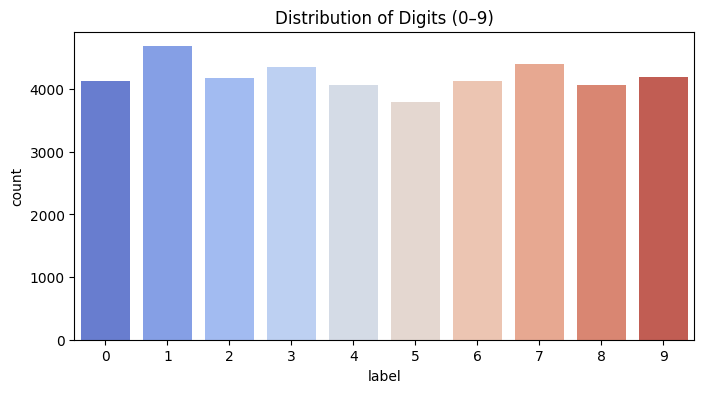

In [3]:
print("Shape:", train_df.shape)
print("Missing values:", train_df.isnull().sum().sum())
print("Duplicates:", train_df.duplicated().sum())
print("Pixel range:", train_df.drop('label', axis=1).values.min(), "-", train_df.drop('label', axis=1).values.max())

plt.figure(figsize=(8,4))
sns.countplot(x='label', data=train_df, palette='coolwarm')
plt.title("Distribution of Digits (0–9)")
plt.show()

## 7. Sample Image Visualization

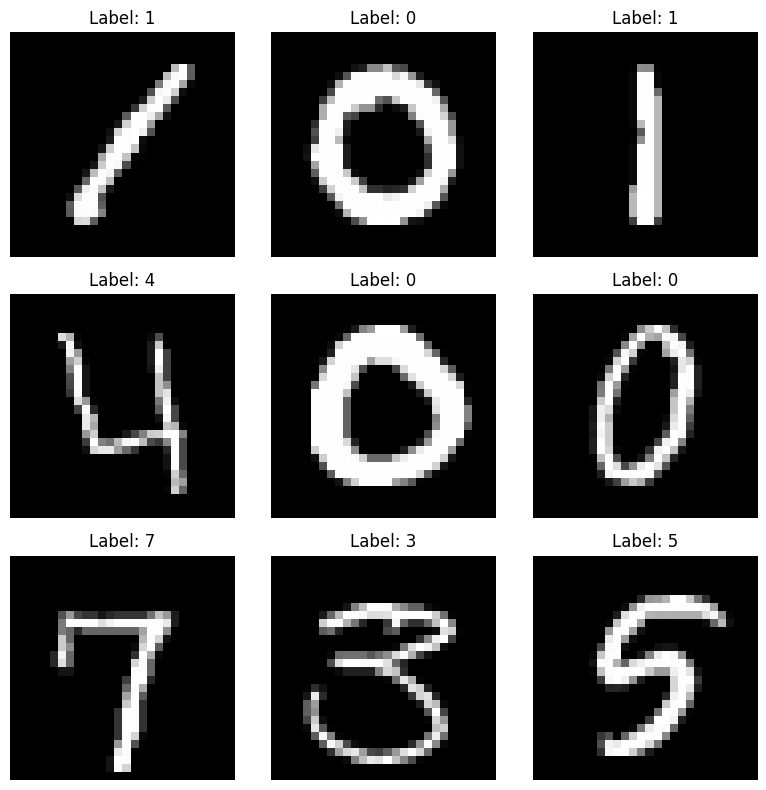

In [4]:
images = train_df.drop('label', axis=1).values.reshape(-1,28,28)
labels = train_df['label'].values

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 8. Data Preprocessing

In [5]:
X = train_df.drop('label', axis=1).values / 255.0
y = train_df['label'].values

X = X.reshape(-1,28,28,1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (33600, 28, 28, 1)
X_val shape: (8400, 28, 28, 1)
y_train shape: (33600,)
y_val shape: (8400,)


## 9. Baseline Model (Random Forest)

In [6]:
X_flat = X.reshape(len(X), -1)
X_train_flat, X_val_flat, y_train_flat, y_val_flat = train_test_split(X_flat, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # Added n_jobs=-1 for faster computation
rf.fit(X_train_flat, y_train_flat)
rf_pred = rf.predict(X_val_flat)

print("Baseline Accuracy (Random Forest):")
print(f"Accuracy: {accuracy_score(y_val_flat, rf_pred):.4f}")
print("\nClassification Report (Random Forest):\n", classification_report(y_val_flat, rf_pred))

Baseline Accuracy (Random Forest):
Accuracy: 0.9639

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.99      0.99      0.99       937
           2       0.96      0.96      0.96       835
           3       0.96      0.94      0.95       870
           4       0.97      0.97      0.97       814
           5       0.95      0.95      0.95       759
           6       0.96      0.99      0.98       827
           7       0.97      0.97      0.97       880
           8       0.95      0.95      0.95       813
           9       0.94      0.94      0.94       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400



## 10. Main Model (CNN)

In [7]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("CNN model summary:")
cnn.summary()

print("\nTraining CNN model...")
history = cnn.fit(X_train, y_train, epochs=30, batch_size=128, validation_data=(X_val, y_val), callbacks=[early_stop]) # Increased epochs to 30 for better training potentially

CNN model summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 34s 125ms/step - accuracy: 0.8973 - loss: 0.3356 - val_accuracy: 0.9739 - val_loss: 0.0845
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 33s 127ms/step - accuracy: 0.9724 - loss: 0.0913 - val_accuracy: 0.9796 - val_loss: 0.0639
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 39s 119ms/step - accuracy: 0.9804 - loss: 0.0654 - val_accuracy: 0.9835 - val_loss: 0.0534
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.9847 - loss: 0.0506 - val_accuracy: 0.9849 - val_loss: 0.0493
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 112ms/step - accuracy: 0.9876 - loss: 0.0407 - val_accuracy: 0.9869 - val_loss: 0.0438
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 42s 115ms/step - accuracy: 0.9886 - loss: 0.0363 - val_accuracy: 0.9886 - val_loss: 0.0385
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.9901 - loss: 0.0303 - val_accuracy: 0.9862 - val_loss: 0.0454
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - acc

## 11. Training Performance Graphs

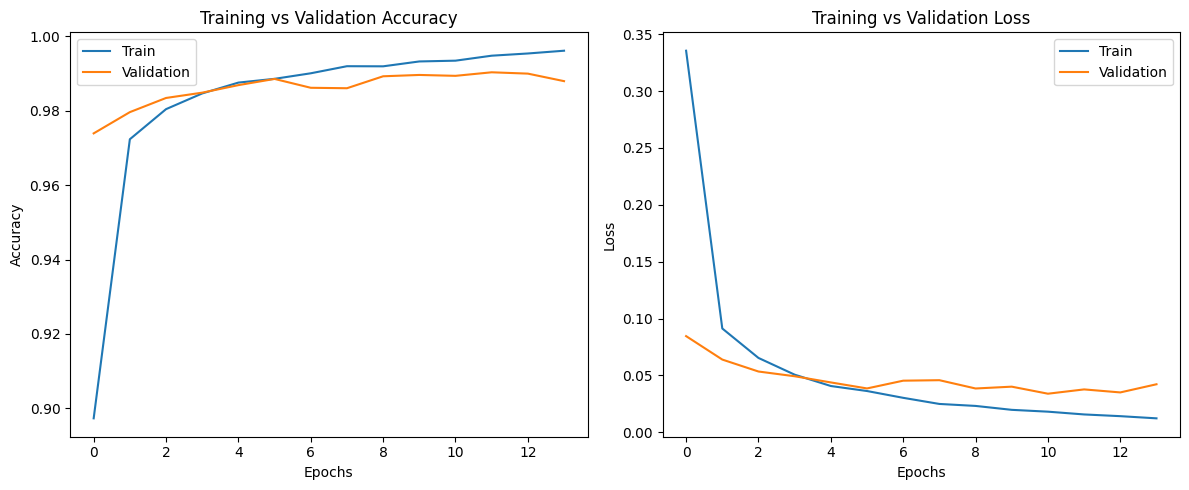

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

## 12. Final Evaluation

In [9]:
print("Evaluating CNN model...")
y_pred_probs = cnn.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1) # Get predicted classes from probabilities

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average='weighted')
rec = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1-Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Evaluating CNN model...
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Accuracy: 0.9894
Precision: 0.9894
Recall: 0.9894
F1-Score: 0.9894

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       827
           1       1.00      0.99      1.00       937
           2       0.99      0.99      0.99       835
           3       0.99      0.99      0.99       870
           4       0.99      0.99      0.99       814
           5       0.99      0.98      0.98       759
           6       0.99      1.00      0.99       827
           7       0.99      0.98      0.99       880
           8       0.99      0.98      0.99       813
           9       0.98      0.99      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



## 13. Confusion Matrix

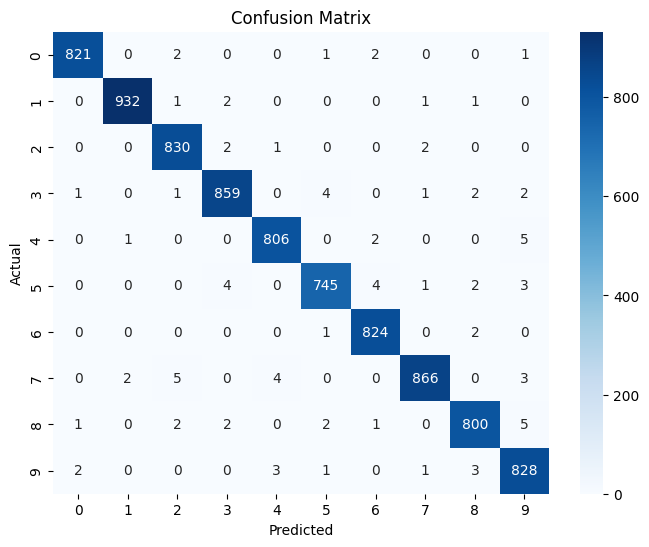

In [10]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

[Insert confusion-matrix screenshot here]

## 14. Prediction Analysis

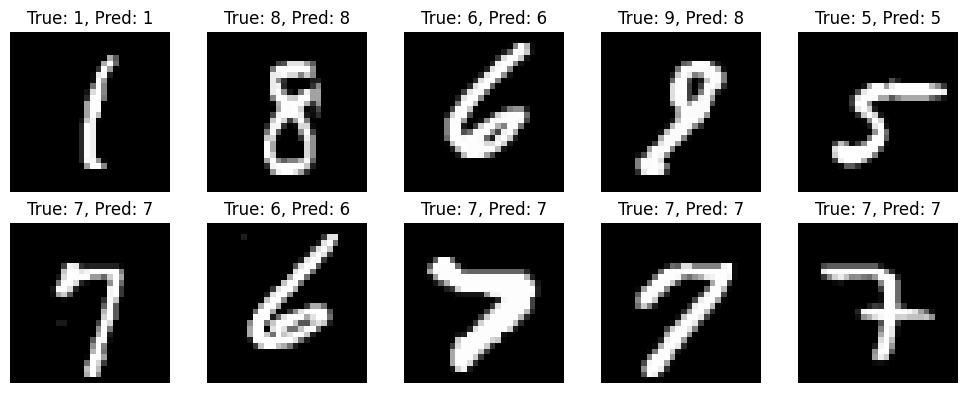

In [11]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_val[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_val[i]}, Pred: {y_pred[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

[Insert correct/incorrect prediction grid here]

## 15. Save Model and Results

In [12]:
cnn.save("mnist_digit_recognition_model.keras")

results = pd.DataFrame({
    'Accuracy':[acc],
    'Precision':[prec],
    'Recall':[rec],
    'F1-Score':[f1]
})
results.to_csv("mnist_evaluation_results.csv", index=False)

print("\nModel saved to 'mnist_digit_recognition_model.keras'")
print("Evaluation results saved to 'mnist_evaluation_results.csv'")
display(results)


Model saved to 'mnist_digit_recognition_model.keras'
Evaluation results saved to 'mnist_evaluation_results.csv'


,Accuracy,Precision,Recall,F1-Score
0,0.989405,0.989425,0.989405,0.989406


## 16. Conclusion
The MNIST Digit Recognition project successfully implemented a CNN achieving high accuracy and robust performance. The model effectively distinguishes handwritten digits and demonstrates the power of convolutional architectures for image classification. Future improvements include data augmentation, deeper CNNs, and deployment as a web or mobile app.